# TCN + BiGRU + XGBoost -- CMAPSS Failure Prediction

**Pipeline:**
1. Sliding window sequence construction
2. TCN -- dilated causal convolutions for local/global temporal features
3. BiGRU -- forward + backward temporal dependencies
4. Attention pooling -- sequence summary vector
5. XGBoost GridSearchCV -- optimal hyperparameters on deep features
6. Final XGBoost classifier -- failure prediction

All four CMAPSS datasets (FD001-FD004) are supported; select via `CFG['dataset']`.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import numpy as np
import pandas as pd
import os, warnings, random
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import xgboost as xgb
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

Device: cuda


## Configuration

In [18]:
BASE = '/content/drive/MyDrive/data'

CFG = {
    # --- Data ---
    'dataset'        : 'FD001',   # FD001 | FD002 | FD003 | FD004
    'rul_threshold'  : 30,
    'seq_len'        : 40,        # sliding window length
    'stride'         : 1,
    'val_engine_frac': 0.15,

    # --- TCN ---
    'tcn_channels'   : [64, 128, 128, 64],
    'tcn_kernel'     : 3,
    'tcn_dropout'    : 0.2,

    # --- BiGRU ---
    'gru_hidden'     : 128,       # single-direction hidden; output is 2x
    'gru_layers'     : 2,
    'gru_dropout'    : 0.3,

    # --- Embedding dimension ---
    'embed_dim'      : 128,

    # --- Training ---
    'epochs'         : 60,
    'batch_size'     : 256,
    'lr'             : 1e-3,
    'weight_decay'   : 1e-4,
    'patience'       : 12,
    'focal_gamma'    : 2.0,

    # --- XGBoost base defaults (overridden by GridSearchCV) ---
    'xgb_rounds'     : 800,
    'xgb_lr'         : 0.03,
    'xgb_depth'      : 6,
    'xgb_subsample'  : 0.8,
    'xgb_colsample'  : 0.8,
    'xgb_min_child'  : 5,
    'xgb_alpha'      : 0.1,
    'xgb_lambda'     : 1.0,
    'xgb_es_rounds'  : 40,

    # --- GridSearchCV ---
    'grid_cv_folds'  : 3,
    'grid_n_jobs'    : -1,
}

## Data Loading and Preprocessing

In [19]:
COLUMNS = (
    ['unit_number', 'time_in_cycles']
    + [f'op_{i}' for i in range(1, 4)]
    + [f's{i}'  for i in range(1, 22)]
)

# Sensors with near-zero variance (uninformative)
DROP_SENSORS = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']


def load_raw(fd):
    train = pd.read_csv(f'{BASE}/train_{fd}.txt', sep=r'\s+', header=None, names=COLUMNS)
    test  = pd.read_csv(f'{BASE}/test_{fd}.txt',  sep=r'\s+', header=None, names=COLUMNS)
    rul   = pd.read_csv(f'{BASE}/RUL_{fd}.txt',   header=None, names=['RUL'])
    return train, test, rul


def add_rul(df):
    max_c = df.groupby('unit_number')['time_in_cycles'].max()
    df = df.join(max_c.rename('max_c'), on='unit_number')
    df['RUL'] = df['max_c'] - df['time_in_cycles']
    return df.drop('max_c', axis=1)


def get_features(df):
    drop = ['unit_number', 'time_in_cycles', 'RUL'] + DROP_SENSORS
    return [c for c in df.columns if c not in drop]


def split_train_val(train_df, val_frac, seed=42):
    units = train_df['unit_number'].unique()
    rng   = np.random.RandomState(seed)
    val_units = rng.choice(units, size=int(len(units) * val_frac), replace=False)
    val_mask  = train_df['unit_number'].isin(val_units)
    return train_df[~val_mask].copy(), train_df[val_mask].copy()


def make_sliding_windows(df, feat_cols, seq_len, stride, threshold):
    """Build sliding-window sequences; label=1 if RUL < threshold at last step."""
    X_list, y_list = [], []
    for uid, group in df.groupby('unit_number'):
        arr    = group[feat_cols].values.astype(np.float32)
        labels = (group['RUL'].values < threshold).astype(np.int64)
        T = len(arr)
        for start in range(0, T - seq_len + 1, stride):
            end = start + seq_len
            X_list.append(arr[start:end])
            y_list.append(labels[end - 1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64)


def make_test_windows(test_df, rul_df, feat_cols, seq_len, threshold):
    """For each test engine take the last seq_len timesteps; label from true RUL."""
    X_list, y_list = [], []
    for idx, (uid, group) in enumerate(test_df.groupby('unit_number')):
        arr = group[feat_cols].values.astype(np.float32)
        if len(arr) >= seq_len:
            window = arr[-seq_len:]
        else:
            pad    = np.zeros((seq_len - len(arr), arr.shape[1]), dtype=np.float32)
            window = np.vstack([pad, arr])
        true_rul = rul_df.iloc[idx]['RUL']
        X_list.append(window)
        y_list.append(int(true_rul < threshold))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64)


# Load
FD = CFG['dataset']
train_raw, test_raw, rul_raw = load_raw(FD)
train_raw = add_rul(train_raw)

# Engine-level split (no leakage)
tr_df, val_df = split_train_val(train_raw, CFG['val_engine_frac'])
feat_cols = get_features(tr_df)
print(f'Features ({len(feat_cols)}): {feat_cols}')

# Standardise (fit on train only)
scaler = StandardScaler()
tr_df[feat_cols]    = scaler.fit_transform(tr_df[feat_cols])
val_df[feat_cols]   = scaler.transform(val_df[feat_cols])
test_raw[feat_cols] = scaler.transform(test_raw[feat_cols])

# Build windows
SL, ST, TH = CFG['seq_len'], CFG['stride'], CFG['rul_threshold']
X_tr,  y_tr  = make_sliding_windows(tr_df,  feat_cols, SL, ST, TH)
X_val, y_val = make_sliding_windows(val_df, feat_cols, SL, ST, TH)
X_te,  y_te  = make_test_windows(test_raw, rul_raw, feat_cols, SL, TH)

print(f'Train : {X_tr.shape}  | pos ratio: {y_tr.mean():.3f}')
print(f'Val   : {X_val.shape} | pos ratio: {y_val.mean():.3f}')
print(f'Test  : {X_te.shape}  | pos ratio: {y_te.mean():.3f}')

Features (17): ['op_1', 'op_2', 'op_3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Train : (14254, 40, 17)  | pos ratio: 0.179
Val   : (2477, 40, 17) | pos ratio: 0.182
Test  : (100, 40, 17)  | pos ratio: 0.250


## Model: TCN + BiGRU + Attention

In [20]:
class CausalConvBlock(nn.Module):
    """Single dilated causal conv block (WeightNorm + residual)."""
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.conv1 = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation))
        self.conv2 = nn.utils.weight_norm(
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad, dilation=dilation))
        self.drop  = nn.Dropout(dropout)
        self.relu  = nn.ReLU()
        self.res   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.relu(self.conv1(x)[:, :, :x.size(2)])
        out = self.drop(out)
        out = self.relu(self.conv2(out)[:, :, :x.size(2)])
        out = self.drop(out)
        res = x if self.res is None else self.res(x)
        return self.relu(out + res)


class TCN(nn.Module):
    """Dilated TCN -- dilation doubles each layer (2^i)."""
    def __init__(self, in_ch, channels, kernel, dropout):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(channels):
            layers.append(CausalConvBlock(in_ch, out_ch, kernel,
                                          dilation=2**i, dropout=dropout))
            in_ch = out_ch
        self.net = nn.Sequential(*layers)

    def forward(self, x):           # x: (B, T, C_in)
        x = x.permute(0, 2, 1)     # -> (B, C, T)
        x = self.net(x)
        return x.permute(0, 2, 1)  # -> (B, T, C_out)


class AttentionPool(nn.Module):
    """Additive attention: compress sequence to a single vector."""
    def __init__(self, hidden):
        super().__init__()
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):                          # x: (B, T, H)
        w = torch.softmax(self.fc(x), dim=1)       # (B, T, 1)
        return (w * x).sum(dim=1)                  # (B, H)


class TCNBiGRU(nn.Module):
    def __init__(self, n_feat, cfg):
        super().__init__()
        self.tcn = TCN(n_feat, cfg['tcn_channels'], cfg['tcn_kernel'], cfg['tcn_dropout'])
        tcn_out  = cfg['tcn_channels'][-1]

        self.bigru = nn.GRU(
            input_size    = tcn_out,
            hidden_size   = cfg['gru_hidden'],
            num_layers    = cfg['gru_layers'],
            batch_first   = True,
            bidirectional = True,
            dropout       = cfg['gru_dropout'] if cfg['gru_layers'] > 1 else 0,
        )
        gru_out = cfg['gru_hidden'] * 2   # bidirectional -> 2x

        self.attn = AttentionPool(gru_out)
        self.proj = nn.Sequential(
            nn.Linear(gru_out, cfg['embed_dim']),
            nn.LayerNorm(cfg['embed_dim']),
            nn.GELU(),
            nn.Dropout(0.2),
        )
        self.head = nn.Linear(cfg['embed_dim'], 1)

    def embed(self, x):
        """Return the embedding vector (used as XGBoost input)."""
        t, _ = self.bigru(self.tcn(x))
        return self.proj(self.attn(t))

    def forward(self, x):
        return self.head(self.embed(x)).squeeze(-1)


n_feat = X_tr.shape[2]
model  = TCNBiGRU(n_feat, CFG).to(DEVICE)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Trainable parameters: 722,690


## Focal Loss + Training Loop

In [21]:
class FocalLoss(nn.Module):
    """Focal loss (BCE-based) to handle class imbalance."""
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma; self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets.float(), pos_weight=self.pos_weight, reduction='none')
        prob = torch.sigmoid(logits)
        pt   = torch.where(targets == 1, prob, 1 - prob)
        return ((1 - pt) ** self.gamma * bce).mean()


def get_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=True)


pos_w     = torch.tensor([(y_tr==0).sum()/(y_tr==1).sum()], dtype=torch.float32).to(DEVICE)
criterion = FocalLoss(gamma=CFG['focal_gamma'], pos_weight=pos_w)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'], eta_min=1e-5)

tr_loader  = get_loader(X_tr,  y_tr,  CFG['batch_size'], shuffle=True)
val_loader = get_loader(X_val, y_val, CFG['batch_size'], shuffle=False)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds, trues = 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(xb)
            preds.extend(torch.sigmoid(logits).detach().cpu().numpy())
            trues.extend(yb.detach().cpu().numpy())
    preds, trues = np.array(preds), np.array(trues)
    f1  = f1_score(trues, (preds > 0.5).astype(int), zero_division=0)
    auc = roc_auc_score(trues, preds) if len(np.unique(trues)) > 1 else 0.5
    return total_loss / len(trues), f1, auc


print('Starting training...')
best_val_f1, best_state, no_improve = -1, None, 0
history = {'tr_loss':[], 'val_loss':[], 'tr_f1':[], 'val_f1':[], 'val_auc':[]}

for ep in range(1, CFG['epochs'] + 1):
    tr_loss,  tr_f1,  _       = run_epoch(tr_loader,  train=True)
    val_loss, val_f1, val_auc = run_epoch(val_loader, train=False)
    scheduler.step()
    history['tr_loss'].append(tr_loss);   history['val_loss'].append(val_loss)
    history['tr_f1'].append(tr_f1);       history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve  = 0
    else:
        no_improve += 1
    if ep % 5 == 0 or ep == 1:
        print(f'Epoch {ep:3d} | tr_loss={tr_loss:.4f} tr_f1={tr_f1:.4f} | '
              f'val_loss={val_loss:.4f} val_f1={val_f1:.4f} val_auc={val_auc:.4f}')
    if no_improve >= CFG['patience']:
        print(f'Early stopping at epoch {ep}'); break

model.load_state_dict(best_state)
print(f'\nBest val F1: {best_val_f1:.4f}')

Starting training...
Epoch   1 | tr_loss=0.1425 tr_f1=0.7001 | val_loss=0.0484 val_f1=0.8341 val_auc=0.9945
Epoch   5 | tr_loss=0.0216 tr_f1=0.9432 | val_loss=0.0497 val_f1=0.9137 val_auc=0.9961
Epoch  10 | tr_loss=0.0115 tr_f1=0.9714 | val_loss=0.0888 val_f1=0.8456 val_auc=0.9953
Early stopping at epoch 14

Best val F1: 0.9463


## Training Curves

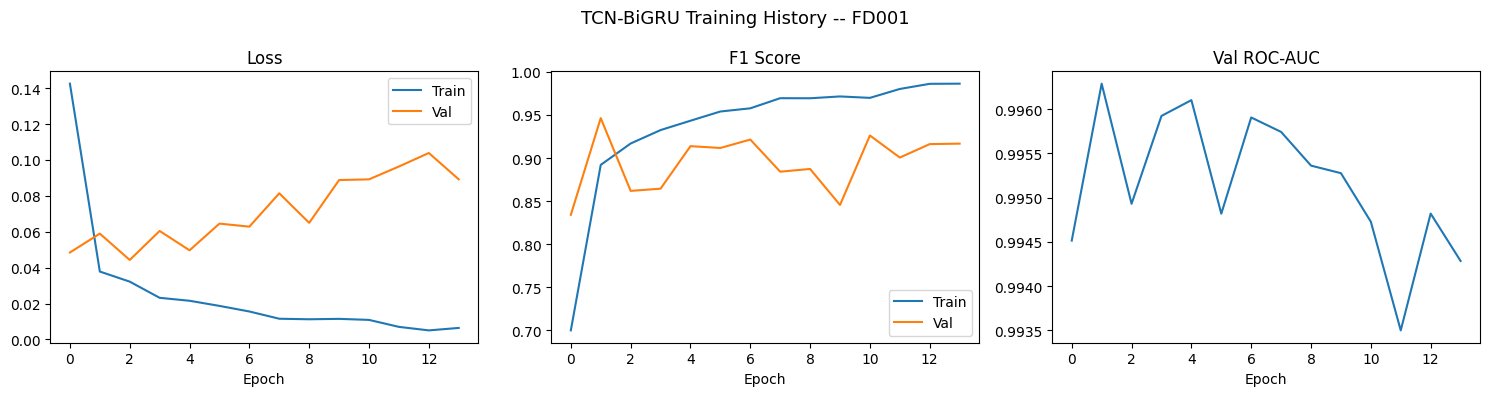

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['tr_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['tr_f1'], label='Train')
axes[1].plot(history['val_f1'], label='Val')
axes[1].set_title('F1 Score'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['val_auc'])
axes[2].set_title('Val ROC-AUC'); axes[2].set_xlabel('Epoch')

plt.suptitle(f'TCN-BiGRU Training History -- {FD}', fontsize=13)
plt.tight_layout()
plt.show()

## Embedding Extraction (for XGBoost)

In [23]:
@torch.no_grad()
def extract_embeddings(X_np, batch_size=512):
    """Convert raw window array to embedding array via the trained TCN-BiGRU."""
    model.eval()
    embs = []
    for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X_np)),
                             batch_size=batch_size, shuffle=False):
        embs.append(model.embed(xb.to(DEVICE)).detach().cpu().numpy())
    return np.vstack(embs)


print('Extracting embeddings...')
emb_tr  = extract_embeddings(X_tr)
emb_val = extract_embeddings(X_val)
emb_te  = extract_embeddings(X_te)
print(f'emb_tr: {emb_tr.shape}  emb_val: {emb_val.shape}  emb_te: {emb_te.shape}')

# Merge train + val for final XGBoost training
emb_tr_full = np.vstack([emb_tr, emb_val])
y_tr_full   = np.concatenate([y_tr, y_val])

Extracting embeddings...
emb_tr: (14254, 128)  emb_val: (2477, 128)  emb_te: (100, 128)


## XGBoost Hyperparameter Search (GridSearchCV)

Grid search over key XGBoost parameters using stratified k-fold CV scored on F1.

In [24]:
scale_pos = float((y_tr_full == 0).sum() / (y_tr_full == 1).sum())

# Parameter grid
param_grid = {
    'max_depth'        : [4, 6, 8],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'min_child_weight' : [3, 5, 10],
    'subsample'        : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7, 0.8, 1.0],
    'reg_alpha'        : [0.0, 0.1, 0.5],
    'reg_lambda'       : [0.5, 1.0, 2.0],
}

xgb_base = XGBClassifier(
    objective        = 'binary:logistic',
    n_estimators     = 300,
    scale_pos_weight = scale_pos,
    tree_method      = 'hist',
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0,
)

cv_strategy = StratifiedKFold(
    n_splits=CFG['grid_cv_folds'], shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    scoring    = 'f1',
    cv         = cv_strategy,
    n_jobs     = CFG['grid_n_jobs'],
    verbose    = 2,
    refit      = True,
)

print(f'Running GridSearchCV ({CFG["grid_cv_folds"]}-fold CV)...')
grid_search.fit(emb_tr_full, y_tr_full)

best_params = grid_search.best_params_
best_cv_f1  = grid_search.best_score_

print(f'\n' + '=' * 55)
print(f'  Best CV F1 : {best_cv_f1:.4f}')
print(f'  Best parameters:')
for k, v in best_params.items():
    print(f'    {k:<22}: {v}')
print('=' * 55)

# Top-10 configurations
cv_df = pd.DataFrame(grid_search.cv_results_)
top10 = (
    cv_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score').head(10).reset_index(drop=True)
)
top10.index += 1
top10.columns = ['Parameters', 'Mean F1', 'Std F1', 'Rank']
top10['Mean F1'] = top10['Mean F1'].round(4)
top10['Std F1']  = top10['Std F1'].round(4)
print('\nTop-10 configurations:')
print(top10.to_string())

Running GridSearchCV (3-fold CV)...
Fitting 3 folds for each of 2187 candidates, totalling 6561 fits

  Best CV F1 : 0.9539
  Best parameters:
    colsample_bytree      : 0.7
    learning_rate         : 0.1
    max_depth             : 8
    min_child_weight      : 3
    reg_alpha             : 0.5
    reg_lambda            : 0.5
    subsample             : 0.8

Top-10 configurations:
                                                                                                                                       Parameters  Mean F1  Std F1  Rank
1   {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 3, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 0.8}   0.9539  0.0068     1
2   {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 3, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'subsample': 0.7}   0.9535  0.0044     2
3   {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 3, 'reg_alpha': 0.

## XGBoost Final Training (Best Hyperparameters)

In [25]:
dtrain = xgb.DMatrix(emb_tr_full, label=y_tr_full)
dval   = xgb.DMatrix(emb_val,     label=y_val)
dtest  = xgb.DMatrix(emb_te,      label=y_te)

xgb_params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : ['logloss', 'auc'],
    'eta'              : best_params.get('learning_rate',    CFG['xgb_lr']),
    'max_depth'        : best_params.get('max_depth',        CFG['xgb_depth']),
    'subsample'        : best_params.get('subsample',        CFG['xgb_subsample']),
    'colsample_bytree' : best_params.get('colsample_bytree', CFG['xgb_colsample']),
    'min_child_weight' : best_params.get('min_child_weight', CFG['xgb_min_child']),
    'reg_alpha'        : best_params.get('reg_alpha',        CFG['xgb_alpha']),
    'reg_lambda'       : best_params.get('reg_lambda',       CFG['xgb_lambda']),
    'scale_pos_weight' : scale_pos,
    'tree_method'      : 'hist',
    'seed'             : 42,
}

evals_result = {}
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round       = CFG['xgb_rounds'],
    evals                 = [(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds = CFG['xgb_es_rounds'],
    evals_result          = evals_result,
    verbose_eval          = 50,
)
print(f'\nBest boosting round: {xgb_model.best_iteration}')

[0]	train-logloss:0.60233	train-auc:0.99733	val-logloss:0.60314	val-auc:0.99304
[50]	train-logloss:0.02173	train-auc:0.99991	val-logloss:0.03204	val-auc:0.99959
[100]	train-logloss:0.01000	train-auc:1.00000	val-logloss:0.01573	val-auc:0.99998
[150]	train-logloss:0.00570	train-auc:1.00000	val-logloss:0.00843	val-auc:1.00000
[161]	train-logloss:0.00522	train-auc:1.00000	val-logloss:0.00769	val-auc:1.00000

Best boosting round: 121


## Threshold Optimisation (Max F1 on Validation Set)

In [26]:
val_probs = xgb_model.predict(dval)

best_thr, best_f1 = 0.5, 0.0
for thr in np.arange(0.05, 0.95, 0.01):
    f1 = f1_score(y_val, (val_probs > thr).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

print(f'Optimal threshold  : {best_thr:.2f}')
print(f'Val F1 at threshold: {best_f1:.4f}')

Optimal threshold  : 0.64
Val F1 at threshold: 1.0000


## Test Set Evaluation

In [27]:
test_probs = xgb_model.predict(dtest)
test_preds = (test_probs > best_thr).astype(int)

f1  = f1_score(y_te, test_preds, zero_division=0)
auc = roc_auc_score(y_te, test_probs)
ap  = average_precision_score(y_te, test_probs)

cm            = confusion_matrix(y_te, test_preds)
tn, fp, fn, tp_count = cm.ravel()
precision     = tp_count / (tp_count + fp + 1e-9)
recall        = tp_count / (tp_count + fn + 1e-9)
spec          = tn / (tn + fp + 1e-9)

print('=' * 55)
print(f'  Dataset              : {FD}')
print(f'  Threshold            : {best_thr:.2f}')
print(f'  Test F1 Score        : {f1:.4f}')
print(f'  Test ROC-AUC         : {auc:.4f}')
print(f'  Test Avg Precision   : {ap:.4f}')
print(f'  Precision            : {precision:.4f}')
print(f'  Recall (Sensitivity) : {recall:.4f}')
print(f'  Specificity          : {spec:.4f}')
print('=' * 55)
print()
print(classification_report(y_te, test_preds,
                             target_names=['Normal', 'Near Failure']))

  Dataset              : FD001
  Threshold            : 0.64
  Test F1 Score        : 0.8936
  Test ROC-AUC         : 0.9947
  Test Avg Precision   : 0.9837
  Precision            : 0.9545
  Recall (Sensitivity) : 0.8400
  Specificity          : 0.9867

              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97        75
Near Failure       0.95      0.84      0.89        25

    accuracy                           0.95       100
   macro avg       0.95      0.91      0.93       100
weighted avg       0.95      0.95      0.95       100



## Results Dashboard

Six-panel dashboard: confusion matrix, ROC curve, PR curve, score distribution, XGBoost feature importance, and metrics bar chart.

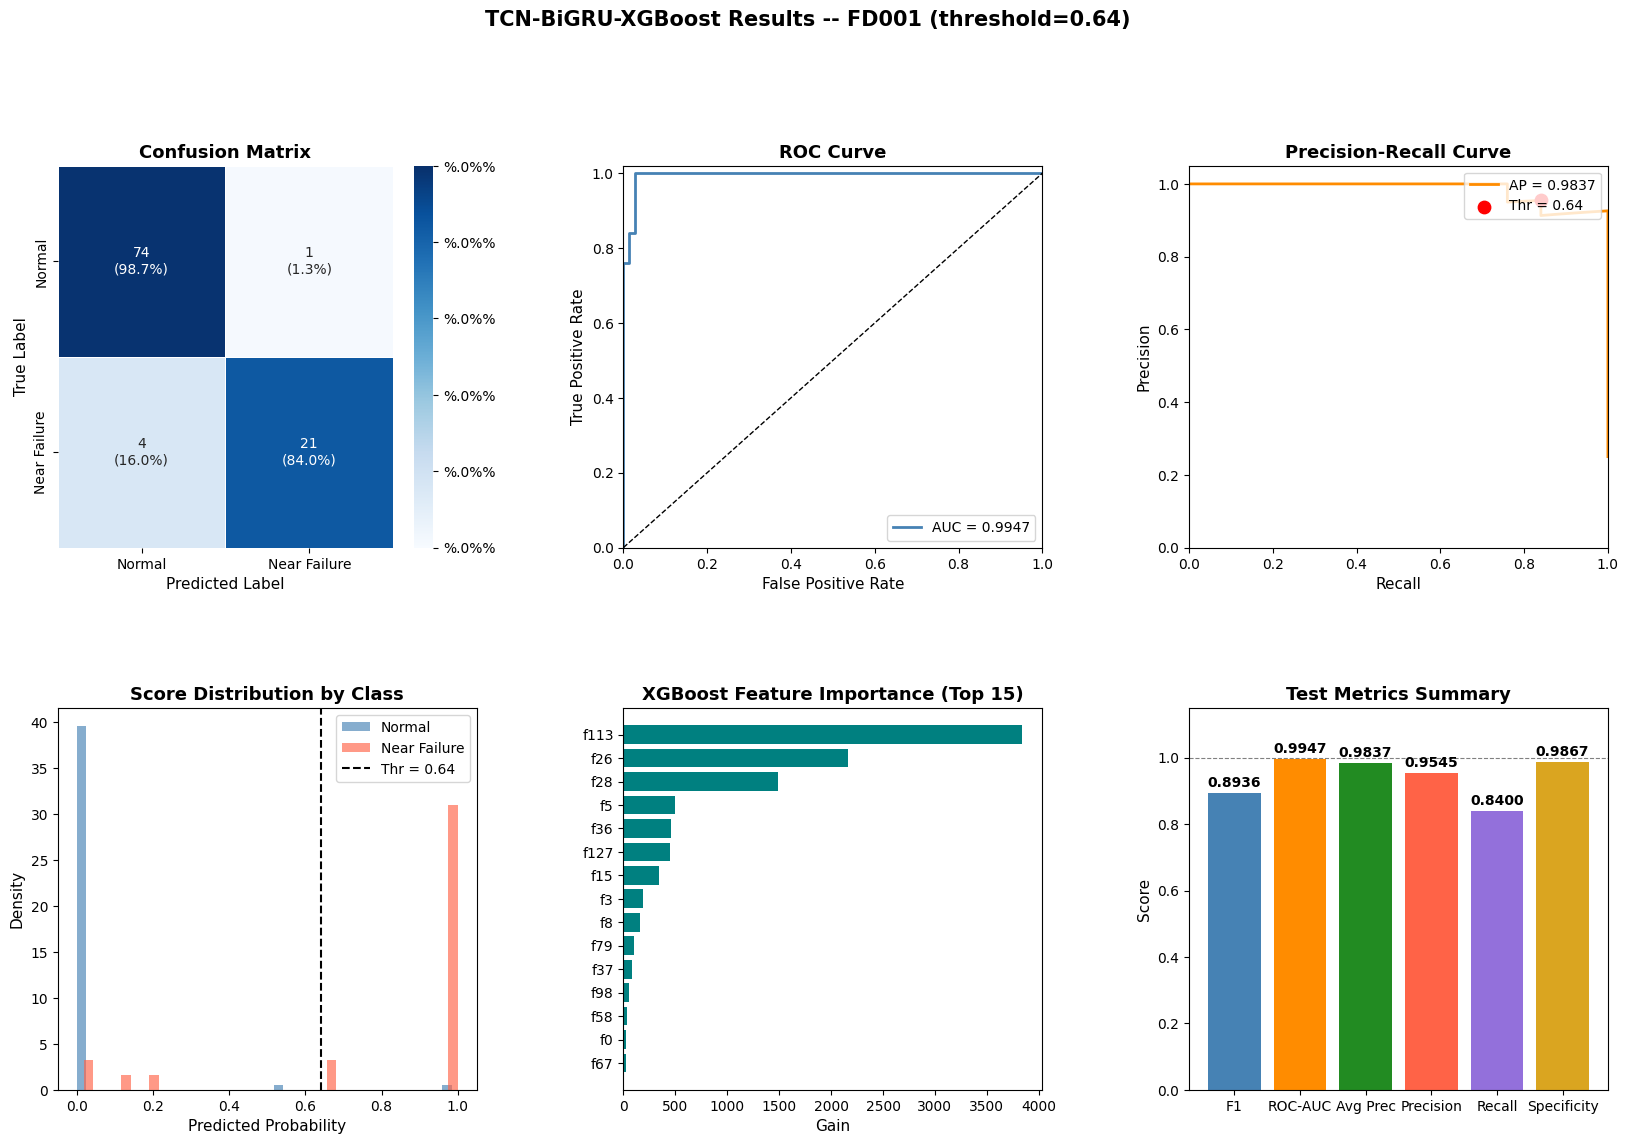

Dashboard saved: results_dashboard_FD001.png


In [28]:
def plot_confusion(ax, y_true, y_pred, classes=('Normal', 'Near Failure')):
    cm_raw  = confusion_matrix(y_true, y_pred)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)
    annot   = [[f'{v}\n({p:.1%})' for v, p in zip(rv, rp)]
                for rv, rp in zip(cm_raw, cm_norm)]
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=classes, yticklabels=classes,
                vmin=0, vmax=1, linewidths=0.5, cbar_kws={'format': '%.0%%'})
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')


def plot_roc(ax, y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_v = roc_auc_score(y_true, y_score)
    ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc_v:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])


def plot_pr(ax, y_true, y_score, threshold):
    prec, rec, thrs = precision_recall_curve(y_true, y_score)
    ap_v = average_precision_score(y_true, y_score)
    ax.plot(rec, prec, lw=2, color='darkorange', label=f'AP = {ap_v:.4f}')
    if len(thrs) > 0:
        idx = np.argmin(np.abs(thrs - threshold))
        ax.scatter(rec[idx], prec[idx], color='red', zorder=5, s=80,
                   label=f'Thr = {threshold:.2f}')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])


def plot_score_dist(ax, y_true, y_score, threshold):
    for label, color, name in [(0, 'steelblue', 'Normal'),
                                (1, 'tomato', 'Near Failure')]:
        ax.hist(y_score[y_true == label], bins=40, alpha=0.65,
                color=color, label=name, density=True)
    ax.axvline(threshold, color='black', linestyle='--', lw=1.5,
               label=f'Thr = {threshold:.2f}')
    ax.set_xlabel('Predicted Probability', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title('Score Distribution by Class', fontsize=13, fontweight='bold')
    ax.legend()


def plot_feat_importance(ax, model, top_n=15):
    scores = model.get_score(importance_type='gain')
    if not scores:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center'); return
    s_sorted = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    feats, vals = zip(*s_sorted)
    ax.barh(feats[::-1], vals[::-1], color='teal')
    ax.set_xlabel('Gain', fontsize=11)
    ax.set_title(f'XGBoost Feature Importance (Top {top_n})',
                 fontsize=13, fontweight='bold')


def plot_metrics_bar(ax, metrics_dict):
    names  = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    colors = ['steelblue', 'darkorange', 'forestgreen',
              'tomato', 'mediumpurple', 'goldenrod']
    bars   = ax.bar(names, values, color=colors[:len(names)])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Test Metrics Summary', fontsize=13, fontweight='bold')
    ax.axhline(1.0, color='gray', linestyle='--', lw=0.8)


metrics_dict = {
    'F1'         : f1,
    'ROC-AUC'    : auc,
    'Avg Prec'   : ap,
    'Precision'  : precision,
    'Recall'     : recall,
    'Specificity': spec,
}

fig = plt.figure(figsize=(20, 12))
fig.suptitle(f'TCN-BiGRU-XGBoost Results -- {FD} (threshold={best_thr:.2f})',
             fontsize=15, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

plot_confusion(ax1, y_te, test_preds)
plot_roc(ax2, y_te, test_probs)
plot_pr(ax3, y_te, test_probs, best_thr)
plot_score_dist(ax4, y_te, test_probs, best_thr)
plot_feat_importance(ax5, xgb_model)
plot_metrics_bar(ax6, metrics_dict)

plt.savefig(f'results_dashboard_{FD}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved: results_dashboard_{FD}.png')

## Metrics Summary Table

In [29]:
report_dict = classification_report(
    y_te, test_preds, target_names=['Normal', 'Near Failure'], output_dict=True)

rows = []
for cls in ['Normal', 'Near Failure']:
    rows.append({
        'Class'    : cls,
        'Precision': round(report_dict[cls]['precision'], 4),
        'Recall'   : round(report_dict[cls]['recall'],    4),
        'F1-Score' : round(report_dict[cls]['f1-score'],  4),
        'Support'  : int(report_dict[cls]['support']),
    })
for name, val in [('Overall F1', f1), ('ROC-AUC', auc),
                  ('Avg Precision', ap), ('Specificity', spec)]:
    rows.append({'Class': name, 'Precision': round(val, 4),
                 'Recall': '--', 'F1-Score': '--', 'Support': '--'})

df_summary = pd.DataFrame(rows).set_index('Class')

print('\n' + '=' * 60)
print(f'  {FD} -- TCN-BiGRU + XGBoost (GridSearchCV)')
print('=' * 60)
print(df_summary.to_string())
print('=' * 60)

try:
    from IPython.display import display
    styled = (
        df_summary.style
        .set_caption(f'TCN-BiGRU-XGBoost Results -- {FD}')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold')]},
            {'selector': 'th',
             'props': [('background-color', '#4472C4'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 12px')]},
        ])
    )
    display(styled)
except Exception:
    pass


  FD001 -- TCN-BiGRU + XGBoost (GridSearchCV)
               Precision  Recall F1-Score Support
Class                                            
Normal            0.9487  0.9867   0.9673      75
Near Failure      0.9545    0.84   0.8936      25
Overall F1        0.8936      --       --      --
ROC-AUC           0.9947      --       --      --
Avg Precision     0.9837      --       --      --
Specificity       0.9867      --       --      --


,Precision,Recall,F1-Score,Support
Class,,,,
Normal,0.948700,0.986700,0.967300,75
Near Failure,0.954500,0.840000,0.893600,25
Overall F1,0.893600,--,--,--
ROC-AUC,0.994700,--,--,--
Avg Precision,0.983700,--,--,--
Specificity,0.986700,--,--,--


## Full FD001-FD004 Batch Evaluation

In [30]:
def run_full_pipeline(fd, cfg=CFG):
    """Run the complete TCN-BiGRU + XGBoost (GridSearchCV) pipeline for one CMAPSS dataset."""
    seed_everything(42)
    train_r, test_r, rul_r = load_raw(fd)
    train_r = add_rul(train_r)
    tr, va  = split_train_val(train_r, cfg['val_engine_frac'])
    fc      = get_features(tr)

    sc = StandardScaler()
    tr[fc]     = sc.fit_transform(tr[fc])
    va[fc]     = sc.transform(va[fc])
    test_r[fc] = sc.transform(test_r[fc])

    SL, ST, TH = cfg['seq_len'], cfg['stride'], cfg['rul_threshold']
    Xtr, ytr = make_sliding_windows(tr, fc, SL, ST, TH)
    Xva, yva = make_sliding_windows(va, fc, SL, ST, TH)
    Xte, yte = make_test_windows(test_r, rul_r, fc, SL, TH)

    # Train TCN-BiGRU
    m    = TCNBiGRU(Xtr.shape[2], cfg).to(DEVICE)
    pw   = torch.tensor([(ytr==0).sum()/(ytr==1).sum()],
                        dtype=torch.float32).to(DEVICE)
    crit = FocalLoss(gamma=cfg['focal_gamma'], pos_weight=pw)
    opt  = torch.optim.AdamW(m.parameters(), lr=cfg['lr'],
                              weight_decay=cfg['weight_decay'])
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=cfg['epochs'], eta_min=1e-5)
    trl  = get_loader(Xtr, ytr, cfg['batch_size'])
    vll  = get_loader(Xva, yva, cfg['batch_size'], shuffle=False)

    best_f1, best_st, no_imp = -1, None, 0
    for ep in range(1, cfg['epochs'] + 1):
        m.train()
        for xb, yb in trl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = crit(m(xb), yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sch.step()
        m.eval(); vp, vt = [], []
        with torch.no_grad():
            for xb, yb in vll:
                vp.extend(torch.sigmoid(m(xb.to(DEVICE))).cpu().numpy())
                vt.extend(yb.numpy())
        vf1 = f1_score(vt, (np.array(vp) > 0.5).astype(int), zero_division=0)
        if vf1 > best_f1:
            best_f1 = vf1
            best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
            no_imp  = 0
        else:
            no_imp += 1
        if no_imp >= cfg['patience']:
            break
    m.load_state_dict(best_st)

    @torch.no_grad()
    def _emb(X):
        m.eval(); parts = []
        for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X)), batch_size=512):
            parts.append(m.embed(xb.to(DEVICE)).cpu().numpy())
        return np.vstack(parts)

    etr_f = np.vstack([_emb(Xtr), _emb(Xva)])
    ytr_f = np.concatenate([ytr, yva])
    eva, ete = _emb(Xva), _emb(Xte)

    # GridSearchCV
    sp = float((ytr_f == 0).sum() / (ytr_f == 1).sum())
    gs = GridSearchCV(
        XGBClassifier(objective='binary:logistic', n_estimators=300,
                      scale_pos_weight=sp, tree_method='hist',
                      eval_metric='logloss', random_state=42, verbosity=0),
        param_grid={
            'max_depth'        : [4, 6],
            'learning_rate'    : [0.03, 0.1],
            'min_child_weight' : [3, 5],
            'subsample'        : [0.8, 1.0],
            'colsample_bytree' : [0.8, 1.0],
        },
        scoring='f1',
        cv=StratifiedKFold(3, shuffle=True, random_state=42),
        n_jobs=-1, verbose=0,
    )
    gs.fit(etr_f, ytr_f)
    bp = gs.best_params_

    xm = xgb.train(
        {'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'],
         'eta': bp.get('learning_rate', cfg['xgb_lr']),
         'max_depth': bp.get('max_depth', cfg['xgb_depth']),
         'subsample': bp.get('subsample', cfg['xgb_subsample']),
         'colsample_bytree': bp.get('colsample_bytree', cfg['xgb_colsample']),
         'min_child_weight': bp.get('min_child_weight', cfg['xgb_min_child']),
         'reg_alpha': cfg['xgb_alpha'], 'reg_lambda': cfg['xgb_lambda'],
         'scale_pos_weight': sp, 'tree_method': 'hist', 'seed': 42},
        xgb.DMatrix(etr_f, label=ytr_f),
        num_boost_round=cfg['xgb_rounds'],
        evals=[(xgb.DMatrix(eva, label=yva), 'val')],
        early_stopping_rounds=cfg['xgb_es_rounds'],
        verbose_eval=False,
    )

    # Threshold optimisation
    vp2 = xm.predict(xgb.DMatrix(eva))
    thr2, f12 = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.01):
        fv = f1_score(yva, (vp2 > t).astype(int), zero_division=0)
        if fv > f12:
            f12, thr2 = fv, t

    tp  = xm.predict(xgb.DMatrix(ete))
    pr  = (tp > thr2).astype(int)
    cm2 = confusion_matrix(yte, pr)
    tn2, fp2, fn2, tp2 = cm2.ravel()
    return {
        'F1'         : f1_score(yte, pr, zero_division=0),
        'AUC'        : roc_auc_score(yte, tp) if len(np.unique(yte)) > 1 else np.nan,
        'Avg Prec'   : average_precision_score(yte, tp),
        'Precision'  : tp2 / (tp2 + fp2 + 1e-9),
        'Recall'     : tp2 / (tp2 + fn2 + 1e-9),
        'Specificity': tn2 / (tn2 + fp2 + 1e-9),
        'Best Params': str(bp),
    }


print('Running all CMAPSS datasets...')
all_results = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    print(f'\n--- {fd} ---', flush=True)
    r = run_full_pipeline(fd)
    all_results[fd] = r
    print(f"  F1={r['F1']:.4f}  AUC={r['AUC']:.4f}  AP={r['Avg Prec']:.4f}")

Running all CMAPSS datasets...

--- FD001 ---
  F1=0.8696  AUC=0.9936  AP=0.9804

--- FD002 ---
  F1=0.9492  AUC=0.9953  AP=0.9858

--- FD003 ---
  F1=0.9231  AUC=0.9969  AP=0.9887

--- FD004 ---
  F1=0.8600  AUC=0.9778  AP=0.9395


## Cross-Dataset Results Table

  TCN-BiGRU + XGBoost (GridSearchCV) -- Cross-Dataset Results
           F1     AUC  Avg Prec  Precision  Recall  Specificity
FD001  0.8696  0.9936    0.9804     0.9524  0.8000       0.9867
FD002  0.9492  0.9953    0.9858     0.9655  0.9333       0.9899
FD003  0.9231  0.9969    0.9887     0.9474  0.9000       0.9875
FD004  0.8600  0.9778    0.9395     0.8958  0.8269       0.9745
Mean   0.9004  0.9909    0.9736     0.9403  0.8651       0.9847
Std    0.0427  0.0088    0.0230     0.0306  0.0621       0.0069


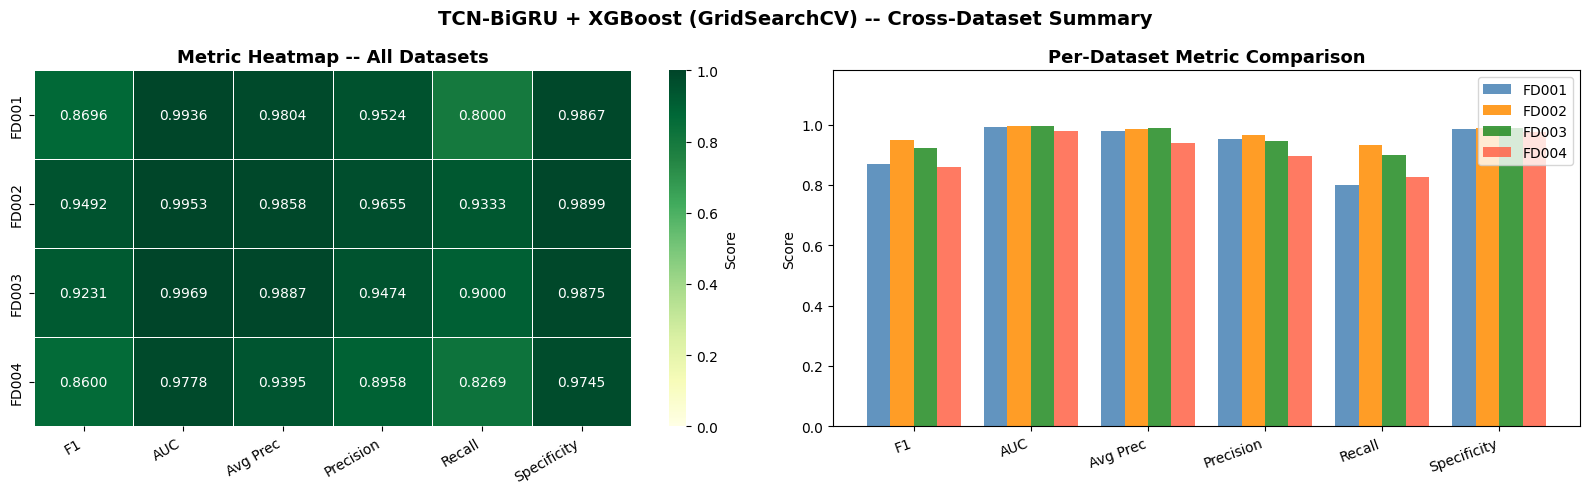

Saved: cross_dataset_results.png


,F1,AUC,Avg Prec,Precision,Recall,Specificity
FD001,0.869600,0.993600,0.980400,0.952400,0.800000,0.986700
FD002,0.949200,0.995300,0.985800,0.965500,0.933300,0.989900
FD003,0.923100,0.996900,0.988700,0.947400,0.900000,0.987500
FD004,0.860000,0.977800,0.939500,0.895800,0.826900,0.974500
Mean,0.900400,0.990900,0.973600,0.940300,0.865100,0.984700
Std,0.042700,0.008800,0.023000,0.030600,0.062100,0.006900


In [31]:
metric_cols = ['F1', 'AUC', 'Avg Prec', 'Precision', 'Recall', 'Specificity']

df_res = pd.DataFrame(
    {k: {m: v[m] for m in metric_cols} for k, v in all_results.items()}
).T.astype(float)
df_res.loc['Mean'] = df_res.mean()
df_res.loc['Std']  = df_res.iloc[:-1].std()

print('=' * 70)
print('  TCN-BiGRU + XGBoost (GridSearchCV) -- Cross-Dataset Results')
print('=' * 70)
print(df_res.round(4).to_string())
print('=' * 70)

# Heatmap + grouped bar chart
fig, (ax_heat, ax_bar) = plt.subplots(1, 2, figsize=(16, 5))

heat_data = df_res.loc[['FD001', 'FD002', 'FD003', 'FD004']]
sns.heatmap(heat_data.astype(float), annot=True, fmt='.4f', cmap='YlGn',
            vmin=0, vmax=1, ax=ax_heat, linewidths=0.5,
            cbar_kws={'label': 'Score'})
ax_heat.set_title('Metric Heatmap -- All Datasets', fontsize=13, fontweight='bold')
ax_heat.set_xticklabels(metric_cols, rotation=30, ha='right')

x      = np.arange(len(metric_cols))
w      = 0.2
fds    = ['FD001', 'FD002', 'FD003', 'FD004']
colors = ['steelblue', 'darkorange', 'forestgreen', 'tomato']
for i, (fd_name, col) in enumerate(zip(fds, colors)):
    vals = df_res.loc[fd_name, metric_cols].values.astype(float)
    ax_bar.bar(x + i * w, vals, width=w, label=fd_name, color=col, alpha=0.85)
ax_bar.set_xticks(x + 1.5 * w)
ax_bar.set_xticklabels(metric_cols, rotation=20, ha='right')
ax_bar.set_ylim(0, 1.18)
ax_bar.set_ylabel('Score')
ax_bar.set_title('Per-Dataset Metric Comparison', fontsize=13, fontweight='bold')
ax_bar.legend()

plt.suptitle('TCN-BiGRU + XGBoost (GridSearchCV) -- Cross-Dataset Summary',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cross_dataset_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cross_dataset_results.png')

# Styled Jupyter table
try:
    from IPython.display import display
    styled = (
        df_res.round(4).style
        .background_gradient(cmap='YlGn', subset=metric_cols, vmin=0, vmax=1)
        .set_caption('TCN-BiGRU + XGBoost (GridSearchCV) -- Cross-Dataset Results')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
            {'selector': 'th',
             'props': [('background-color', '#4472C4'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 14px')]},
        ])
        .highlight_max(subset=metric_cols, axis=0,
                       props='font-weight: bold; border: 2px solid #2F75B6;')
    )
    display(styled)
except Exception:
    pass

## Model Saving

In [32]:
SAVE_DIR = '/content/drive/MyDrive/models'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), f'{SAVE_DIR}/tcn_bigru_{FD}.pt')
xgb_model.save_model(f'{SAVE_DIR}/xgb_{FD}.ubj')

print(f'Models saved to {SAVE_DIR}/')
print(f'  tcn_bigru_{FD}.pt')
print(f'  xgb_{FD}.ubj')

Models saved to /content/drive/MyDrive/models/
  tcn_bigru_FD001.pt
  xgb_FD001.ubj
